In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [14]:
import fastf1

In [15]:
fastf1.Cache.enable_cache('./f1_cache')

In [16]:
df = pd.read_parquet('voltas_f1.parquet')
df.shape

(26604, 34)

In [17]:
df.head()

,Ano,Rodada,Evento,Sessao,Driver,DriverNumber,Team,LapNumber,Stint,LapTime,...,PitInTime,PitOutTime,LapStartDate,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection
0,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26604 entries, 0 to 26603
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Ano            26604 non-null  int64         
 1   Rodada         26604 non-null  int64         
 2   Evento         26604 non-null  object        
 3   Sessao         26604 non-null  object        
 4   Driver         26604 non-null  object        
 5   DriverNumber   26604 non-null  object        
 6   Team           26604 non-null  object        
 7   LapNumber      26604 non-null  float64       
 8   Stint          26604 non-null  float64       
 9   LapTime        26381 non-null  float64       
 10  Sector1Time    26066 non-null  float64       
 11  Sector2Time    26574 non-null  float64       
 12  Sector3Time    26553 non-null  float64       
 13  SpeedI1        26578 non-null  float64       
 14  SpeedI2        26578 non-null  float64       
 15  SpeedFL        2573

In [19]:
df.isnull().sum()

Ano                  0
Rodada               0
Evento               0
Sessao               0
Driver               0
DriverNumber         0
Team                 0
LapNumber            0
Stint                0
LapTime            223
Sector1Time        538
Sector2Time         30
Sector3Time         51
SpeedI1             26
SpeedI2             26
SpeedFL            874
SpeedST             32
Compound             0
TyreLife             0
FreshTyre            0
TrackStatus          0
Position            26
IsAccurate           0
Deleted              0
PitInTime        25755
PitOutTime       25764
LapStartDate         0
AirTemp              0
TrackTemp            0
Humidity             0
Pressure             0
Rainfall             0
WindSpeed            0
WindDirection        0
dtype: int64

In [20]:
df.columns = df.columns.str.lower().str.replace(' ', '_') #Limpeza de dados

In [21]:
df.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
0,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,Bahrain Grand Prix,R,VER,1,Red Bull Racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [22]:
strings = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])] #Limpeza de dados

In [23]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_') #Limpeza de dados

In [24]:
df.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
0,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,1.0,1.0,97.284,...,NaN,NaN,2024-03-02 15:03:42.342,18.2,23.8,49.0,1017.2,False,1.5,58
1,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,2.0,1.0,96.296,...,NaN,NaN,2024-03-02 15:05:19.920,18.3,23.8,49.0,1017.0,False,1.1,33
2,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,3.0,1.0,96.753,...,NaN,NaN,2024-03-02 15:06:56.216,18.3,23.8,49.0,1017.1,False,1.5,89
3,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,4.0,1.0,96.647,...,NaN,NaN,2024-03-02 15:08:32.969,18.3,23.7,49.0,1017.0,False,0.9,24
4,2024,1,bahrain_grand_prix,r,ver,1,red_bull_racing,5.0,1.0,97.173,...,NaN,NaN,2024-03-02 15:10:09.616,18.3,23.5,50.0,1017.1,False,1.5,40


In [25]:
df.evento.unique()

array(['bahrain_grand_prix', 'saudi_arabian_grand_prix',
       'australian_grand_prix', 'japanese_grand_prix',
       'chinese_grand_prix', 'miami_grand_prix',
       'emilia_romagna_grand_prix', 'monaco_grand_prix',
       'canadian_grand_prix', 'spanish_grand_prix', 'austrian_grand_prix',
       'british_grand_prix', 'hungarian_grand_prix', 'belgian_grand_prix',
       'dutch_grand_prix', 'italian_grand_prix', 'azerbaijan_grand_prix',
       'singapore_grand_prix', 'united_states_grand_prix',
       'mexico_city_grand_prix', 'são_paulo_grand_prix',
       'las_vegas_grand_prix', 'qatar_grand_prix', 'abu_dhabi_grand_prix'],
      dtype=object)

In [26]:
df_monza = df[df['evento'] == 'italian_grand_prix'] #Filtro para apenas a corrida de Monza

#Monza foi escolhido, pois não houve safety car na corrida afetando os tempos das voltas
#Além disso vitoria da ferrari, leclerc ganhou.

In [27]:
df_monza.head() 

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
17122,2024,16,italian_grand_prix,r,lec,16,ferrari,1.0,1.0,88.179,...,NaN,NaN,2024-09-01 13:03:34.413,33.8,51.3,32.0,993.2,False,1.9,191
17123,2024,16,italian_grand_prix,r,lec,16,ferrari,2.0,1.0,85.396,...,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,False,1.4,218
17124,2024,16,italian_grand_prix,r,lec,16,ferrari,3.0,1.0,85.179,...,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,False,2.3,185
17125,2024,16,italian_grand_prix,r,lec,16,ferrari,4.0,1.0,84.810,...,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,False,1.9,201
17126,2024,16,italian_grand_prix,r,lec,16,ferrari,5.0,1.0,84.603,...,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,False,1.8,194


In [28]:
df_monza = df_monza.reset_index(drop = True)

In [29]:
df_monza['driver'].value_counts() #Contagem de voltas por piloto

driver
lec    53
pia    53
nor    53
sai    53
ham    53
ver    53
rus    53
per    53
alb    53
mag    53
alo    53
col    53
ric    53
oco    52
gas    52
bot    52
hul    52
zho    52
str    52
tsu     7
Name: count, dtype: int64

In [30]:
df_monza.groupby(['driver', 'stint'])['lapnumber'].agg(['min', 'max'])

min   max
driver stint            
alb    1.0     1.0  17.0
       2.0    18.0  53.0
alo    1.0     1.0  12.0
       2.0    13.0  35.0
       3.0    36.0  53.0
bot    1.0     1.0  33.0
       2.0    34.0  52.0
col    1.0     1.0  16.0
       2.0    17.0  53.0
gas    1.0     1.0  10.0
       2.0    11.0  30.0
       3.0    31.0  52.0
ham    1.0     1.0  15.0
       2.0    16.0  37.0
       3.0    38.0  53.0
hul    1.0     1.0   5.0
       2.0     6.0  32.0
       3.0    33.0  52.0
lec    1.0     1.0  15.0
       2.0    16.0  53.0
mag    1.0     1.0  14.0
       2.0    15.0  53.0
nor    1.0     1.0  14.0
       2.0    15.0  32.0
       3.0    33.0  53.0
oco    1.0     1.0  31.0
       2.0    32.0  52.0
per    1.0     1.0  23.0
       2.0    24.0  35.0
       3.0    36.0  53.0
pia    1.0     1.0  16.0
       2.0    17.0  38.0
       3.0    39.0  53.0
ric    1.0     1.0  11.0
       2.0    12.0  53.0
rus    1.0     1.0  11.0
       2.0    12.0  33.0
       3.0    34.0  53.0
sai    1.0     1.0  19.0
       2.0    20.0  53.0
str    1.0     1.0  19.0
       2.0    20.0  36.0
       3.0    37.0  50.0
       4.0    51.0  52.0
tsu    1.0     1.0   7.0
ver    1.0     1.0  22.0
       2.0    23.0  41.0
       3.0    42.0  53.0
zho    1.0     1.0  15.0
       2.0    16.0  52.0

In [31]:
mask = (
    df_monza['pitintime'].isna()
    & df_monza['pitouttime'].isna()
    & (df_monza['lapnumber'] != 1.0)
)

df_clean_monza = df_monza[mask] #Removendo voltas de entrada e saída do box, além da primeira volta(perda de tempo na largada)

In [32]:
df_clean_monza.head()

,ano,rodada,evento,sessao,driver,drivernumber,team,lapnumber,stint,laptime,...,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,rainfall,windspeed,winddirection
1,2024,16,italian_grand_prix,r,lec,16,ferrari,2.0,1.0,85.396,...,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,False,1.4,218
2,2024,16,italian_grand_prix,r,lec,16,ferrari,3.0,1.0,85.179,...,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,False,2.3,185
3,2024,16,italian_grand_prix,r,lec,16,ferrari,4.0,1.0,84.810,...,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,False,1.9,201
4,2024,16,italian_grand_prix,r,lec,16,ferrari,5.0,1.0,84.603,...,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,False,1.8,194
5,2024,16,italian_grand_prix,r,lec,16,ferrari,6.0,1.0,84.663,...,NaN,NaN,2024-09-01 13:10:42.838,33.5,50.2,31.0,993.1,False,2.0,192


In [33]:
df_clean_monza['trackstatus'].value_counts()

trackstatus
1    927
Name: count, dtype: int64

In [34]:
df_monza['trackstatus'].astype(str).str.contains('4', na=False).sum() #Vendo se houve safety car na corrida

np.int64(0)

In [35]:
df_clean_monza.nunique() #Vendo quais colunas tem '1', quer dizer que não mudaram em lugar algum e podemos remover

ano                1
rodada             1
evento             1
sessao             1
driver            20
drivernumber      20
team              10
lapnumber         52
stint              4
laptime          836
sector1time      581
sector2time      736
sector3time      734
speedi1           36
speedi2           44
speedfl           19
speedst           58
compound           3
tyrelife          42
freshtyre          2
trackstatus        1
position          20
isaccurate         1
deleted            2
pitintime          0
pitouttime         0
lapstartdate     927
airtemp           17
tracktemp         42
humidity           4
pressure           7
rainfall           1
windspeed         17
winddirection     35
dtype: int64

<Axes: xlabel='laptime', ylabel='Count'>

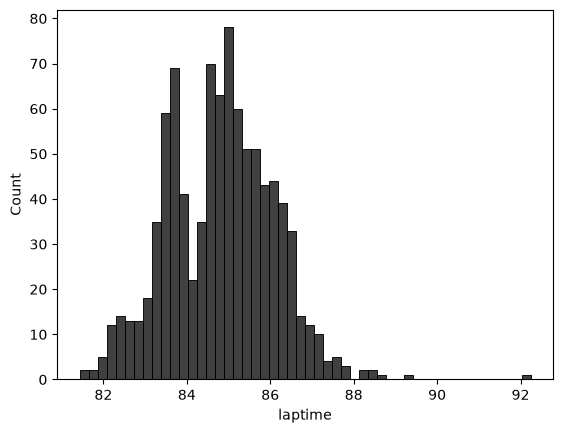

In [36]:
sns.histplot(df_clean_monza.laptime, bins = 50, color = 'black') #Gráfico de tempos de volta

In [37]:
df_clean_monza = df_clean_monza.drop(columns=[
    'ano', 'rodada', 'evento', 'sessao',
    'trackstatus', 'isaccurate', 'rainfall'
])

In [38]:
df_clean_monza.head()

,driver,drivernumber,team,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,...,deleted,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
1,lec,16,ferrari,2.0,1.0,85.396,27.707,29.265,28.424,315.0,...,False,NaN,NaN,2024-09-01 13:05:02.850,33.9,50.5,31.0,993.2,1.4,218
2,lec,16,ferrari,3.0,1.0,85.179,27.679,29.001,28.499,313.0,...,False,NaN,NaN,2024-09-01 13:06:28.246,33.7,50.6,30.0,993.3,2.3,185
3,lec,16,ferrari,4.0,1.0,84.810,27.653,28.883,28.274,314.0,...,False,NaN,NaN,2024-09-01 13:07:53.425,33.7,50.6,31.0,993.2,1.9,201
4,lec,16,ferrari,5.0,1.0,84.603,27.630,28.790,28.183,313.0,...,False,NaN,NaN,2024-09-01 13:09:18.235,33.7,50.6,31.0,993.2,1.8,194
5,lec,16,ferrari,6.0,1.0,84.663,27.596,28.945,28.122,315.0,...,False,NaN,NaN,2024-09-01 13:10:42.838,33.5,50.2,31.0,993.1,2.0,192


In [39]:
df_clean_monza.columns

Index(['driver', 'drivernumber', 'team', 'lapnumber', 'stint', 'laptime',
       'sector1time', 'sector2time', 'sector3time', 'speedi1', 'speedi2',
       'speedfl', 'speedst', 'compound', 'tyrelife', 'freshtyre', 'position',
       'deleted', 'pitintime', 'pitouttime', 'lapstartdate', 'airtemp',
       'tracktemp', 'humidity', 'pressure', 'windspeed', 'winddirection'],
      dtype='object')

In [40]:
df_clean_monza = df_clean_monza[df_clean_monza.driver != 'tsu'] #Retirando tsunoda, abandonou com 7 voltas por bater no hulkenberg

<Axes: xlabel='laptime', ylabel='Count'>

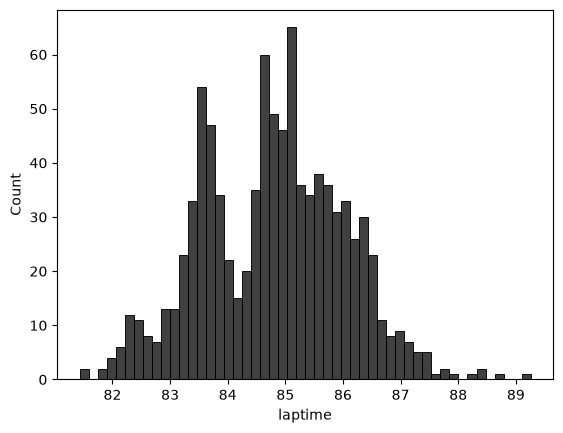

In [41]:
sns.histplot(df_clean_monza.laptime, bins = 50, color = 'black')

In [42]:
df_clean_monza.describe() #Analisando features interessantes para uso

,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,speedi2,speedfl,speedst,...,position,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
count,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000,...,922.000000,0.0,0.0,922,922.000000,922.000000,922.000000,922.000000,922.000000,922.000000
mean,27.535792,1.877440,84.788775,27.620282,29.005137,28.163357,314.099783,319.199566,312.383948,325.019523,...,9.918655,NaN,NaN,2024-09-01 13:41:47.034820096,32.752061,46.387419,31.532538,992.983406,1.574946,192.486985
min,2.000000,1.000000,81.432000,26.877000,27.439000,26.804000,225.000000,213.000000,294.000000,279.000000,...,1.000000,NaN,NaN,2024-09-01 13:05:02.294000,32.200000,43.600000,30.000000,992.700000,0.600000,0.000000
25%,14.000000,1.000000,83.762750,27.432000,28.590250,27.757000,312.000000,315.000000,311.000000,320.000000,...,5.000000,NaN,NaN,2024-09-01 13:22:43.929499904,32.500000,44.900000,31.000000,992.900000,1.300000,188.000000
50%,28.000000,2.000000,84.852500,27.592000,29.003000,28.189000,314.000000,318.000000,312.000000,323.000000,...,10.000000,NaN,NaN,2024-09-01 13:41:59.932499968,32.600000,45.800000,32.000000,993.000000,1.600000,196.000000
75%,41.000000,2.000000,85.674750,27.753000,29.379750,28.513750,316.000000,322.000000,314.000000,328.000000,...,15.000000,NaN,NaN,2024-09-01 14:01:00.957000192,32.900000,47.600000,32.000000,993.000000,1.800000,201.000000
max,53.000000,4.000000,89.256000,29.201000,31.159000,30.350000,335.000000,343.000000,322.000000,357.000000,...,20.000000,NaN,NaN,2024-09-01 14:18:12.978000,33.900000,50.600000,33.000000,993.300000,2.400000,239.000000
std,15.116030,0.687369,1.239248,0.282505,0.553532,0.504763,5.459039,8.273243,2.580744,8.331855,...,5.480882,NaN,NaN,NaN,0.434956,1.996891,0.663557,0.112112,0.369569,27.738118


In [43]:
#Framework de validação

In [44]:
n = len(df_clean_monza)

n_val = int(len(df_clean_monza) * 0.2)
n_test = int(len(df_clean_monza) * 0.2)
n_train = n - n_val - n_test

n

922

In [45]:
n_val, n_test, n_train

(184, 184, 554)

In [46]:
idx = np.arange(n)

In [47]:
np.random.seed(2)
np.random.shuffle(idx) #aleatório 60/20/20, deixando obrigatório, porque as linhas são ordenadas por piloto

In [48]:
df_train = df_clean_monza.iloc[idx[:n_train]]
df_val = df_clean_monza.iloc[idx[n_train:n_train + n_val]]
df_test = df_clean_monza.iloc[idx[n_train + n_val:]]

In [49]:
df_train.head()

,driver,drivernumber,team,lapnumber,stint,laptime,sector1time,sector2time,sector3time,speedi1,...,deleted,pitintime,pitouttime,lapstartdate,airtemp,tracktemp,humidity,pressure,windspeed,winddirection
333,rus,63,mercedes,16.0,2.0,84.692,27.635,28.894,28.163,315.0,...,False,NaN,NaN,2024-09-01 13:25:33.414,32.8,47.8,30.0,993.1,1.9,195
420,per,11,red_bull_racing,50.0,3.0,83.390,27.408,28.351,27.631,312.0,...,False,NaN,NaN,2024-09-01 14:13:34.159,32.3,44.1,32.0,992.9,1.6,196
861,hul,27,haas_f1_team,17.0,2.0,86.119,28.068,29.532,28.519,312.0,...,False,NaN,NaN,2024-09-01 13:27:15.566,32.9,47.2,31.0,993.0,1.7,195
252,ham,44,mercedes,41.0,3.0,82.927,27.270,28.351,27.306,312.0,...,False,NaN,NaN,2024-09-01 14:00:43.850,32.5,44.7,32.0,992.9,1.6,201
592,col,43,williams,10.0,1.0,86.289,27.760,29.706,28.823,317.0,...,False,NaN,NaN,2024-09-01 13:16:44.248,33.3,48.6,31.0,993.0,1.8,196


In [50]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True) #Matriz X de características

In [51]:
y_train = df_train.laptime.values
y_test = df_test.laptime.values
y_val = df_val.laptime.values #Alvos

In [52]:
del df_train['laptime']
del df_val['laptime']
del df_test['laptime'] #Removendo variável alvo

## Regressão linear

$x_i$ são as características do carro, clima, piloto e $y_i$ é o tempo de volta:

$$g(x_i) \approx y_i$$

Temos que ter uma função que receba todas essas características e produza algo próximo do tempo de volta do piloto.

$$g(x_i) = w_0 + (w_1 x_{i1}) + (w_2 x_{i2}) + (w_3 x_{i3})$$

$w_0$ é a previsão sem saber nada sobre as características, $w_1 x_{i1}$ = características, $w_2 x_{i2}$ = características.

Ou seja...

$$g(x_i) = w_0 + \sum_j (w_j x_{ij})$$

previsão sem saber nada (viés) + o somatório das características $\times$ peso.

Assumindo que $x_{i0} = 1$:

$$g(x_i) = \sum_j w_j x_{ij}$$

Generalizando para a forma vetorial, devemos transpor o vetor de características $x_i$ e a soma vira um produto escalar:

$$g(x_i) = w_0 + x_i^{T} w$$

$$w = [w_0, w_1, w_2, w_3, \dots, w_n] \qquad x_i = [x_{i0} = 1,\, x_{i1},\, x_{i2},\, \dots,\, x_{in}]$$

$$w^{T} x_i = x_i^{T} w = w_0 + \dots$$

## Forma matricial

$X$ é matriz de características, sendo uma linha para cada info da volta do piloto-carro, e a previsão sai com uma multiplicação matriz-vetor.

$$\hat{y} = Xw$$

## Treinando o modelo

Para obter os pesos:

$$g(X) = Xw \approx y$$

Significa que a matriz de características vezes o vetor de pesos deve ser próximo de $y$.

## Para achar $w$

Caso $X$ fosse uma matriz quadrada e invertível, era só multiplicar os dois lados de $Xw = y$ por $X^{-1}$. Viraria:

$$X^{-1} X w = X^{-1} y \qquad \text{onde} \qquad X^{-1} X = I$$

Então:

$$w = X^{-1} y$$

Mas $X$ é uma matriz **retangular**, tem mais dados (linhas) do que colunas — esse tipo de matriz é definido por $m \times (n+1)$ — então a inversão não existe.

Portanto:

$$(X^{T} X)^{-1} X^{T} X w = (X^{T} X)^{-1} X^{T} y$$

Deixamos a matriz quadrada, assim é possível cortar $(X^{T} X)^{-1} X^{T} X$ por $I$:

$$w = (X^{T} X)^{-1} X^{T} y$$

In [53]:
df_train.columns

Index(['driver', 'drivernumber', 'team', 'lapnumber', 'stint', 'sector1time',
       'sector2time', 'sector3time', 'speedi1', 'speedi2', 'speedfl',
       'speedst', 'compound', 'tyrelife', 'freshtyre', 'position', 'deleted',
       'pitintime', 'pitouttime', 'lapstartdate', 'airtemp', 'tracktemp',
       'humidity', 'pressure', 'windspeed', 'winddirection'],
      dtype='object')

In [55]:
base = ['lapnumber','tyrelife']

X_train = df_train[base].values

In [61]:
X_train = df_train[base].fillna(0)

In [62]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = (np.column_stack([ones, X]))

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv).round(1)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [63]:
w0, w = train_linear_regression(X_train, y_train)

In [64]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

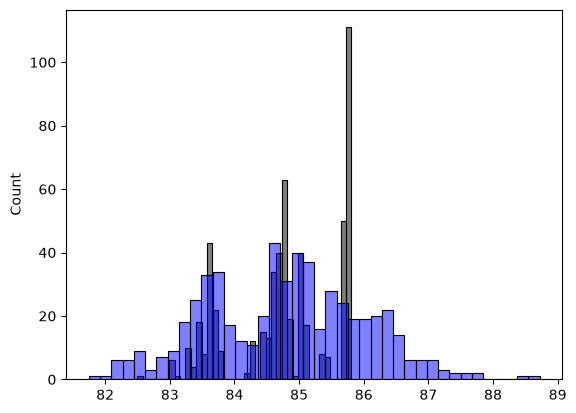

In [69]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 40) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 40) #Azul = variáveis alvo

In [70]:
#Avaliação do modelo de regressã(erro quadratico medio -> RMSE
#RMSE = √1/m * ∑(g(xi)(*previsao para xi) - yi(*valor real))ˆ2

#Decompondo:
#(g(xi) - yi)ˆ2 -> diferença entre a previsão e o valor real, o quadrado pune os erros maiores

#Isso apresentado acima é o erro quadrático, agora calculamos a média e a raiz de 1/m.

In [71]:
def rmse(y, y_pred):
    se = (y - y_pred) **2
    mse = se.mean()
    
    return np.sqrt(mse) 

In [73]:
rmse(y_train, y_pred) 
#Erro otimista de treino
#Esse valor mostrou que o modelo aprendeu 0.82 contra um baseline de 1,24, ≈ 46% da variância explicada com 2 colunas.

np.float64(0.8999730784844006)

In [74]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [75]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.820123321023398)

<Axes: ylabel='Count'>

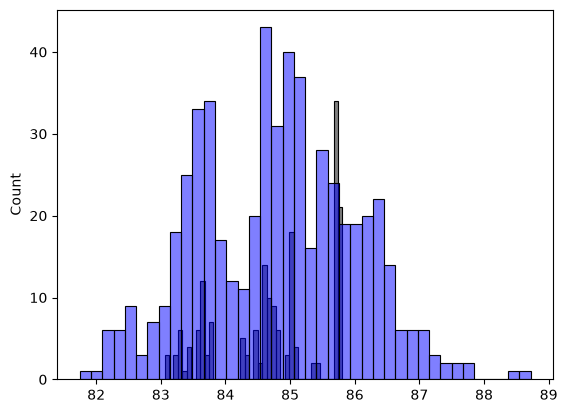

In [76]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 40) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 40) #Azul = variáveis alvo

In [77]:
#Aqui a validação foi melhor que o treino, por causa do ruído amostral, temos 184 voltas.
#Com essas voltas aquele subconjunto caiu com voltas um pouco mais previsíveis 

In [81]:
w

#Esse resultado '-0.06500663' quer dizer que a cada volta o carro fica -0.0650 mais rápido + evolução da pista.
#O pneu vai soltando borracha ao longo da pista, gerando mais aderência a cada volta.

#Ou seja isso é o tanque do carro esvaziando, carro fica leve e anda mais rápido

#E o resultado '0.06224527' quer dizer que a cada volta do pneu o carro fica +0.062 mais lento
#Isso é a degradação

#O modelo separou os dois pelas descontinuidades. As paradas são a fonte de identificação

#Dentro de um stint de pneu esses números avançam juntos, a correlação deles é exatamento 1,0(em um stint)
#Então o efeito líquido de andar mais uma volta é -0,0650 + 0,0622 = -0,0028 p/volta
#Praticamente zero, dois efeitos físicos grande de sinais opostos e magnitudes quase idênticas
#Antes quase descartei a feature pela correlação marginal de -0,034, era quase zero pq o pneu importa tanto como o combustível nessa pista de monza
#Se eu descartassse era 0,062 s/volta em 20 voltas de stint, mais de um segundo de degradação invisível no modelo.

array([-0.06500663,  0.06224527])

In [80]:
#Mais features para melhorar o modelo

In [88]:
base_features = ['lapnumber', 'tyrelife', 'freshtyre']


def prepare_X(
    df: pd.DataFrame,
    categorical_to_encode: dict[str, list],
) -> np.ndarray:
    df = df.copy()
    features = base_features.copy()

    for column, values in categorical_to_encode.items():
        for value in values:
            feature_name = f"{column}_{value}"

            df[feature_name] = (
                df[column] == value
            ).astype(int)

            features.append(feature_name)

    df_num = df[features].fillna(0)

    return df_num.values.astype(float)


In [90]:
all_drivers = sorted(df_train['driver'].unique())

driver_ref = 'lec' #piloto referência por ter ganhado a corrida
categorical_to_encode = {
    'driver':   [d for d in sorted(df_train['driver'].unique())   if d != 'lec'],
    'compound': [c for c in sorted(df_train['compound'].unique()) if c != 'hard'],
}

X_train = prepare_X(df_train, categorical_to_encode)
X_val   = prepare_X(df_val,   categorical_to_encode)

w0, w = train_linear_regression(X_train, y_train)

y_pred_val = w0 + X_val.dot(w)
rmse(y_val, y_pred_val)

np.float64(0.5317608714610901)

<Axes: ylabel='Count'>

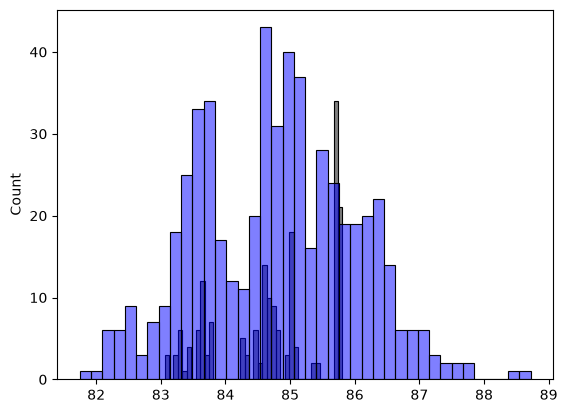

In [91]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 40) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 40) #Azul = variáveis alvo

In [92]:
#Histograma mede a forma das duas distribuições

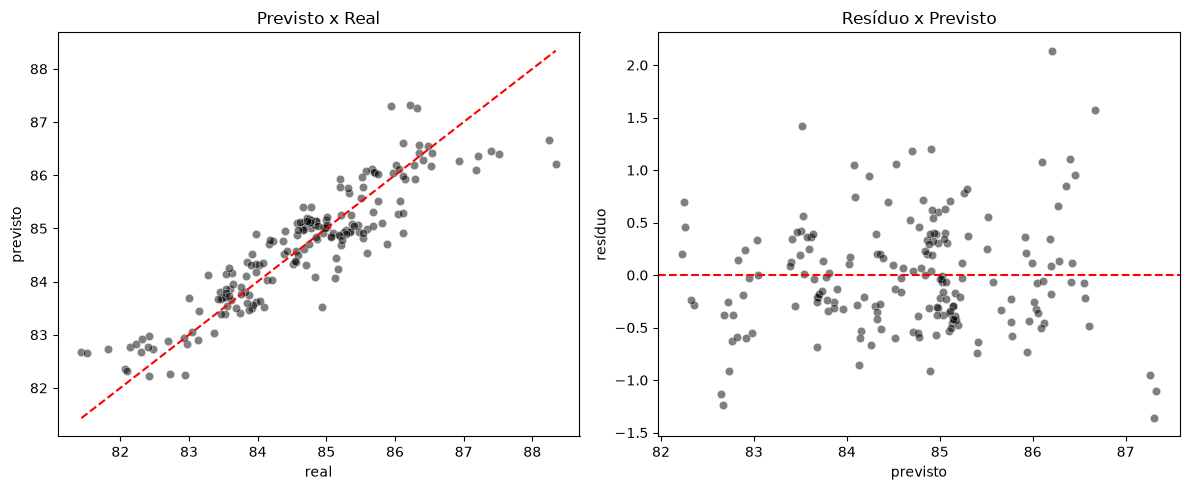

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) previsto x real
sns.scatterplot(x=y_val, y=y_pred_val, color='black', alpha=0.5, ax=axes[0])
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
axes[0].plot(lims, lims, color='red', linestyle='--')
axes[0].set_xlabel('real')
axes[0].set_ylabel('previsto')
axes[0].set_title('Previsto x Real')

# 2) resíduo x previsto
residuos = y_val - y_pred_val
sns.scatterplot(x=y_pred_val, y=residuos, color='black', alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('previsto')
axes[1].set_ylabel('resíduo')
axes[1].set_title('Resíduo x Previsto')

plt.tight_layout()


In [ ]:
#Os pontos conseguem acompanhar a diagonal com uma certa dispersão razoável, coerente com a correlação de 0,906.

#É perceptivo também que o desvio em voltas rápidas é menor do que em voltas lentas; 
#Isso ocorre, porque voltas rápidas costumam ser mais bem feitas, são voltas limpas e portanto previsíveis.;
#Voltas lentas, podem ser lentas por diversos motivos, por isso são difíceis de prever.